<a href="https://colab.research.google.com/github/giministk/ml/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964_%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_K_%D0%B1%D0%BB%D0%B8%D0%B6%D0%B0%D0%B9%D1%88%D0%B8%D1%85_%D1%81%D0%BE%D1%81%D0%B5%D0%B4%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №6. Метод K-ближайших соседей

# Базовый алгоритм KNN

## KNN для классификации

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 1. KNN из sklearn

#### 1.1. Разбейте данные на обучение и тест

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=20)
X_train.shape, X_test.shape

((130, 4), (20, 4))

#### 1.2. Обучите модель KNN

In [ ]:
# Импортируем класс KNeighborsClassifier из модуля sklearn.neighbors
from sklearn.neighbors import KNeighborsClassifier

# Устанавливаем количество соседей для алгоритма kNN
n_neighbors = 3

# Создаем экземпляр классификатора KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=n_neighbors)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

#### 1.3. Проверьте качество работы модели

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(acc)

0.95


#### 1.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

In [ ]:
n_neighbors = 1
scores = []
neig = []

while n_neighbors < 11:
  model = KNeighborsClassifier(n_neighbors=n_neighbors)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  scores.append(acc)
  neig.append(n_neighbors)
  n_neighbors += 1

df = pd.DataFrame({'n_neighbors':neig, 'score':scores})
df

,n_neighbors,score
0,1,0.95
1,2,0.95
2,3,0.95
3,4,0.95
4,5,0.95
5,6,0.95
6,7,0.95
7,8,0.95
8,9,0.95
9,10,1.00


### 2. KNN рукописный

#### 2.1. Возьмите два случайных тестовых объектов

In [ ]:
test1 = X_test.iloc[3]
test2 = X_test.iloc[4]
print(test1, test2)

sepal length (cm)    6.1
sepal width (cm)     3.0
petal length (cm)    4.6
petal width (cm)     1.4
Name: 91, dtype: float64 sepal length (cm)    5.0
sepal width (cm)     3.3
petal length (cm)    1.4
petal width (cm)     0.2
Name: 49, dtype: float64


#### 2.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [ ]:
import numpy as np
tests = [test1, test2]
dist = pd.DataFrame()
dist['trained'] = y_train
for i in range(len(tests)):
  samp = tests[i].values
  distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
  dist[f'distance to {i} obj'] = distto
print(dist)

     trained  distance to 0 obj  distance to 1 obj
0          2           1.783255           5.325411
1          2           1.330413           4.883646
2          2           0.500000           3.976179
3          0           3.252691           0.547723
4          1           0.458258           3.229551
..       ...                ...                ...
125        2           0.964365           4.162932
126        1           1.126943           2.563201
127        0           3.567913           1.322876
128        2           1.835756           5.345091
129        0           3.570714           0.264575

[130 rows x 3 columns]


#### 2.3. Выберите топ $k$ соседей для каждого объекта

In [ ]:
k = 10
d0 = dist.sort_values('distance to 0 obj').head(k)
d1 = dist.sort_values('distance to 1 obj').head(k)
print(d0)
print(d1)

     trained  distance to 0 obj  distance to 1 obj
37         1           0.141421           3.701351
33         1           0.200000           3.529873
121        1           0.300000           3.653765
11         1           0.346410           3.349627
34         1           0.387298           3.642801
24         1           0.424264           3.813135
82         1           0.447214           3.426368
4          1           0.458258           3.229551
104        2           0.458258           3.900000
115        1           0.458258           3.798684
     trained  distance to 0 obj  distance to 1 obj
71         0           3.524202           0.141421
120        0           3.595831           0.223607
83         0           3.556684           0.223607
60         0           3.535534           0.244949
73         0           3.563706           0.244949
119        0           3.682391           0.244949
129        0           3.570714           0.264575
20         0           3.371943

#### 2.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [ ]:
print('pred1: ', d0['trained'].value_counts().index[0])
print('pred2: ', d1['trained'].value_counts().index[0])

pred1:  1
pred2:  0


#### 2.5. Сравните с настоящими целевыми значениями этих двух объектов

In [ ]:
print(y_test[3])
print(y_test[4])

1
0


## KNN для регрессии

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### KNN из sklearn

#### 3.1. Разбейте данные на обучение и тест

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,              # Матрица признаков
    y,              # Вектор целевых значений
    random_state=10,# Фиксируем генератор случайных чисел для воспроизводимости
    test_size=10    # Размер тестовой выборки (10 образцов)
)

X_train.shape, X_test.shape

((20630, 8), (10, 8))

Затем нормализуйте данные:

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(X_train)

X_train = pd.DataFrame(mms.transform(X_train[X_train.columns]), columns=X_train.columns)
X_test = pd.DataFrame(mms.transform(X_test[X_train.columns]), columns=X_train.columns)

#### 3.2. Обучите модель KNN


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
n_neighbors = 30

model = KNeighborsRegressor(n_neighbors=n_neighbors)

model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=30)

#### 3.3. Проверьте качество работы модели

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred_test = model.predict(X_test)
r2_score(y_test, pred_test)

0.6550778763781642

#### 3.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

In [ ]:
n_neighbors = 20
score1 = []
neig1 = []

while n_neighbors < 31:
  model = KNeighborsRegressor(n_neighbors=n_neighbors)
  model.fit(X_train, y_train)
  pred_test = model.predict(X_test)
  r2 = r2_score(y_test, pred_test)
  score1.append(r2)
  neig1.append(n_neighbors)
  n_neighbors += 1

df = pd.DataFrame({'n_neighbors':neig1, 'score':score1})
df

,n_neighbors,score
0,20,0.659463
1,21,0.653672
2,22,0.666222
3,23,0.677832
4,24,0.657760
5,25,0.664721
6,26,0.682211
7,27,0.666586
8,28,0.655763
9,29,0.659344


### 4. KNN рукописный

#### 4.1. Возьмите два случайных тестовых объектов

In [ ]:
test1 = X_test.iloc[3]
test2 = X_test.iloc[4]
print(test1, test2)

MedInc        0.179549
HouseAge      0.549020
AveRooms      0.026591
AveBedrms     0.020861
Population    0.056336
AveOccup      0.003193
Latitude      0.166844
Longitude     0.637450
Name: 3, dtype: float64 MedInc        0.287768
HouseAge      0.098039
AveRooms      0.034624
AveBedrms     0.020751
Population    0.027075
AveOccup      0.001806
Latitude      0.453773
Longitude     0.446215
Name: 4, dtype: float64


#### 4.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [ ]:
tests = [test1, test2]
dist = pd.DataFrame()
dist['trained'] = y_train
for i in range(len(tests)):
  samp = tests[i].values
  distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
  dist[f'distance to {i} obj'] = distto
print(dist)

       trained  distance to 0 obj  distance to 1 obj
0      1.37800           0.675899           0.828221
1      5.00001           0.108871           0.500844
2      1.57900           0.320955           0.846877
3      1.09400           0.626623           0.333899
4      0.88900           0.425325           0.203338
...        ...                ...                ...
20625  3.10300           0.635566           0.674804
20626  2.55000           0.254529           0.480825
20627  2.41900           0.702958           0.210207
20628  1.50000           0.137225           0.686272
20629  1.91100           0.578016           0.317404

[20630 rows x 3 columns]


#### 4.3. Выберите топ $k$ соседей для каждого объекта

In [ ]:
k = 10
d0 = dist.sort_values('distance to 0 obj').head(k)
d1 = dist.sort_values('distance to 1 obj').head(k)
print(d0)
print(d1)

       trained  distance to 0 obj  distance to 1 obj
17204    1.136           0.022346           0.588226
16363    1.811           0.023882           0.563196
19190    1.639           0.024534           0.569162
4057     1.641           0.025283           0.592363
3504     1.592           0.025293           0.584612
9970     1.921           0.026660           0.598517
11750    1.542           0.026777           0.593719
8235     1.955           0.028745           0.579804
19708    1.860           0.029694           0.577869
1701     1.418           0.031767           0.594474
       trained  distance to 0 obj  distance to 1 obj
8030     0.931           0.570919           0.019987
18651    0.884           0.550819           0.047471
11700    1.144           0.608066           0.048977
2212     0.895           0.548683           0.049132
20255    0.830           0.581010           0.049930
14653    1.137           0.610695           0.053244
15431    1.002           0.551596           0.

#### 4.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [ ]:
print('pred1: ', d0['trained'].value_counts().index[0])
print('pred2: ', d1['trained'].value_counts().index[0])

pred1:  1.136
pred2:  0.931


#### 4.5. Сравните с настоящими целевыми значениями этих двух объектов

In [ ]:
print(y_test[3])
print(y_test[4])

1.408
1.078


Предсказания отклоняются от истины, но не так сильно, они довольно близки.

# Weighted KNN

## KNN для классификации

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Выберите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [ ]:
sepal_le = X[['sepal length (cm)', 'petal width (cm)']]
sepal_le

,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2
...,...,...
145,6.7,2.3
146,6.3,1.9
147,6.5,2.0
148,6.2,2.3


### Визуализируйте ваши данные на графике

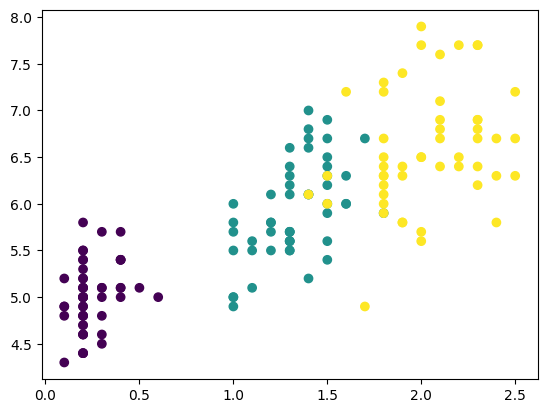

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(sepal_le['petal width (cm)'], sepal_le['sepal length (cm)'], c=y)
plt.show()

### 1. KNN из sklearn

#### 1.1. Разбейте данные на обучение и тест

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(sepal_le, y, random_state=6, test_size=30)
X_train.shape, X_test.shape

((120, 2), (30, 2))

#### 1.2. Обучите модель KNN на 50 соседях

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 50
model = KNeighborsClassifier(n_neighbors=n_neighbors)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50)

#### 1.3. Проверьте качество работы модели

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
bal_acc = accuracy_score(y_test, y_pred)
print(bal_acc)

0.8666666666666667


#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
test1 = X_test.iloc[4]
dist = pd.DataFrame()
dist['trained'] = y_train
samp = test1.values
distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
dist['distance to 0 obj'] = distto
print(dist)

     trained  distance to 0 obj
0          0           2.121320
1          1           1.170470
2          0           1.664332
3          0           2.624881
4          2           0.300000
..       ...                ...
115        2           0.509902
116        1           1.000000
117        2           1.140175
118        2           1.403567
119        2           0.300000

[120 rows x 2 columns]


#### 1.5. Выберите топ  k  соседей


In [ ]:
k = 50
d0 = dist.sort_values('distance to 0 obj').head(k)
print(d0)

     trained  distance to 0 obj
11         2           0.000000
95         2           0.100000
7          2           0.100000
24         2           0.141421
62         1           0.200000
44         2           0.282843
107        2           0.282843
119        2           0.300000
4          2           0.300000
106        1           0.316228
5          2           0.316228
92         1           0.360555
30         1           0.360555
19         1           0.360555
86         2           0.400000
82         1           0.400000
29         2           0.400000
43         2           0.412311
109        1           0.412311
85         1           0.424264
58         1           0.447214
52         2           0.447214
94         1           0.447214
13         1           0.500000
110        1           0.500000
100        1           0.500000
79         2           0.500000
115        2           0.509902
42         2           0.509902
37         2           0.509902
49      

#### 1.6. Выведите финальное предсказание для этого объекта

In [ ]:
print('pred1: ', d0['trained'].value_counts().index[0])

pred1:  2


#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [ ]:
print(y_test[4])

2


#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

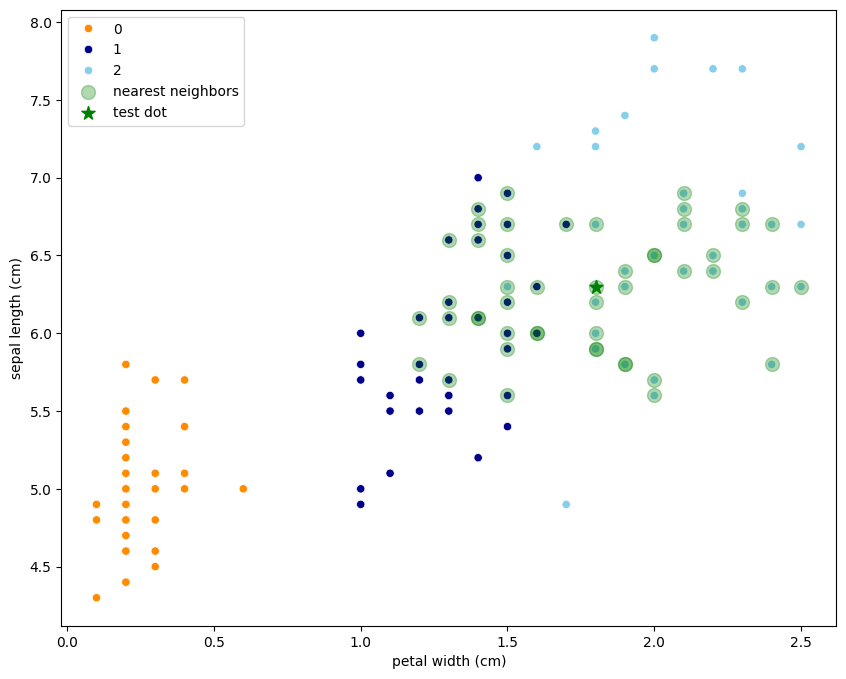

In [ ]:
import seaborn as sns

nearest_neigbors_idxs = dist.sort_values('distance to 0 obj').head(k).index

cmap_bold = ["darkorange", "darkblue", 'skyblue']

# Создаем новую фигуру размером 10x8
plt.figure(figsize=(10, 8))

# Визуализируем обучающие данные с помощью scatter plot
sns.scatterplot(
    x=X_train['petal width (cm)'],  # Первый признак для оси X
    y=X_train['sepal length (cm)'],  # Второй признак для оси Y
    hue=y_train,      # Цвет точек зависит от класса
    palette=cmap_bold # Используем нашу цветовую палитру
)

# Добавляем на график ближайших соседей
plt.scatter(X_train['petal width (cm)'].iloc[nearest_neigbors_idxs], X_train['sepal length (cm)'].iloc[nearest_neigbors_idxs],
            c='g',            # Зеленый цвет для ближайших соседей
            alpha=0.3,        # Устанавливаем прозрачность
            marker='o',       # Используем круглые маркеры
            s=100,            # Размер маркеров
            label='nearest neighbors')  # Метка для легенды

# Добавляем тестовую точку на график
plt.scatter(X_test['petal width (cm)'].iloc[4], X_test['sepal length (cm)'].iloc[4],
            c='g',            # Зеленый цвет для тестовой точки
            marker='*',       # Используем звездочку для обозначения тестовой точки
            s=100,            # Размер маркера
            label='test dot') # Метка для легенды

# Добавляем легенду на график
plt.legend()

### 2. Weighted KNN

#### 2.1. Обучите модель "взвешенный KNN" по дистанции

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 50
model = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance')
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 2.2. Проверьте качество работы модели


In [ ]:
from sklearn.metrics import balanced_accuracy_score
y_pred = model.predict(X_test)
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(bal_acc)

0.9060606060606061


#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
test1 = X_test.iloc[4]
dist = pd.DataFrame()
dist['trained'] = y_train
samp = test1.values
distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
dist['distance to 0 obj'] = distto
print(dist)

     trained  distance to 0 obj
0          0           2.121320
1          1           1.170470
2          0           1.664332
3          0           2.624881
4          2           0.300000
..       ...                ...
115        2           0.509902
116        1           1.000000
117        2           1.140175
118        2           1.403567
119        2           0.300000

[120 rows x 2 columns]


#### 2.4. Выберите топ  k  соседей


In [ ]:
k = 50
d0 = dist.sort_values('distance to 0 obj').head(k)
print(d0)

     trained  distance to 0 obj
11         2           0.000000
95         2           0.100000
7          2           0.100000
24         2           0.141421
62         1           0.200000
44         2           0.282843
107        2           0.282843
119        2           0.300000
4          2           0.300000
106        1           0.316228
5          2           0.316228
92         1           0.360555
30         1           0.360555
19         1           0.360555
86         2           0.400000
82         1           0.400000
29         2           0.400000
43         2           0.412311
109        1           0.412311
85         1           0.424264
58         1           0.447214
52         2           0.447214
94         1           0.447214
13         1           0.500000
110        1           0.500000
100        1           0.500000
79         2           0.500000
115        2           0.509902
42         2           0.509902
37         2           0.509902
49      

#### 2.5. Рассчитайте вес для каждого соседа

In [ ]:
dist['weight'] = 1 / dist['distance to 0 obj']
dist['weight'].replace(np.inf, 0, inplace=True) # на случай деления на 0
dist

/tmp/ipykernel_419/979074447.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dist['weight'].replace(np.inf, 0, inplace=True) # на случай деления на 0


,trained,distance to 0 obj,weight
0,0,2.121320,0.471405
1,1,1.170470,0.854358
2,0,1.664332,0.600842
3,0,2.624881,0.380970
4,2,0.300000,3.333333
...,...,...,...
115,2,0.509902,1.961161
116,1,1.000000,1.000000
117,2,1.140175,0.877058
118,2,1.403567,0.712470


#### 2.6. Выведите финальное предсказание для этого объекта

In [ ]:
print('pred0: ', dist[dist['trained'] == 0]['weight'].sum())
print('pred1: ', dist[dist['trained'] == 1]['weight'].sum())
print('pred2: ', dist[dist['trained'] == 2]['weight'].sum())

pred0:  20.46116630896271
pred1:  67.0966831836094
pred2:  87.31286069786908


#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [ ]:
print(y_test[4])

2


#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

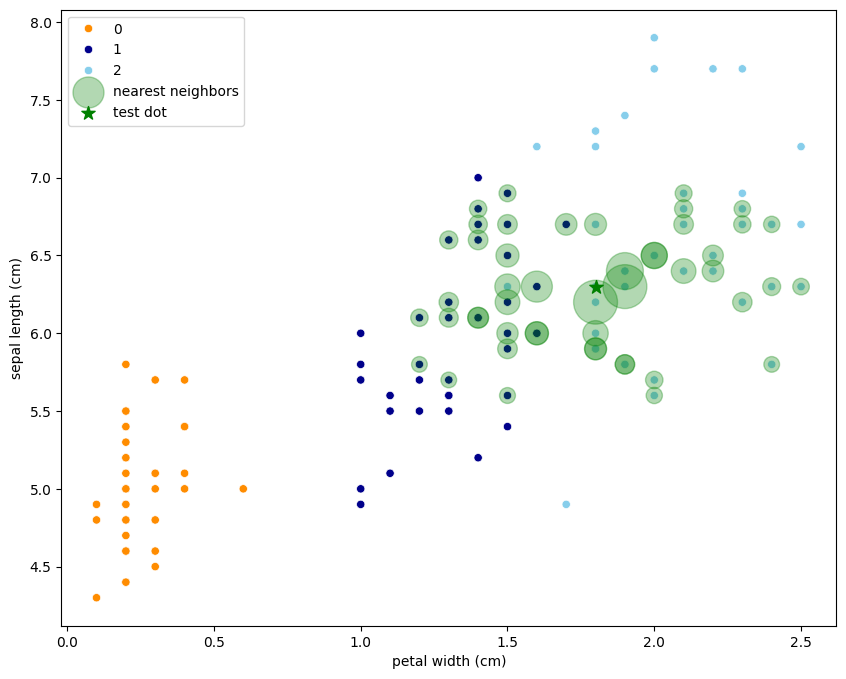

In [ ]:
import seaborn as sns

nearest_neigbors_idxs = dist.sort_values('distance to 0 obj').head(k).index

cmap_bold = ["darkorange", "darkblue", 'skyblue']

# Создаем новую фигуру размером 10x8
plt.figure(figsize=(10, 8))

# Визуализируем обучающие данные с помощью scatter plot
sns.scatterplot(
    x=X_train['petal width (cm)'],  # Первый признак для оси X
    y=X_train['sepal length (cm)'],  # Второй признак для оси Y
    hue=y_train,      # Цвет точек зависит от класса
    palette=cmap_bold # Используем нашу цветовую палитру
)

# Добавляем на график ближайших соседей
plt.scatter(X_train['petal width (cm)'].iloc[nearest_neigbors_idxs], X_train['sepal length (cm)'].iloc[nearest_neigbors_idxs],
            c='g',            # Зеленый цвет для ближайших соседей
            alpha=0.3,        # Устанавливаем прозрачность
            marker='o',       # Используем круглые маркеры
            s=dist['weight'].iloc[nearest_neigbors_idxs]*100,            # Размер маркеров
            label='nearest neighbors')  # Метка для легенды

# Добавляем тестовую точку на график
plt.scatter(X_test['petal width (cm)'].iloc[4], X_test['sepal length (cm)'].iloc[4],
            c='g',            # Зеленый цвет для тестовой точки
            marker='*',       # Используем звездочку для обозначения тестовой точки
            s=100,            # Размер маркера
            label='test dot') # Метка для легенды

# Добавляем легенду на график
plt.legend()

### 3. Еще одна задача классификации

### Получение данных

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
import pandas as pd


data = fetch_olivetti_faces(shuffle=True, random_state=9)

X = pd.DataFrame(data['data'])
y = data['target']

X.head()

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0.723140,0.710744,0.714876,0.731405,0.735537,0.752066,0.772727,0.793388,0.814050,0.834711,...,0.793388,0.904959,0.549587,0.409091,0.491736,0.487603,0.471074,0.483471,0.475207,0.475207
1,0.289256,0.157025,0.148760,0.190083,0.169421,0.194215,0.404959,0.607438,0.669421,0.677686,...,0.438017,0.400826,0.421488,0.429752,0.433884,0.425620,0.438017,0.438017,0.210744,0.206612
2,0.586777,0.595041,0.681818,0.694215,0.714876,0.698347,0.714876,0.727273,0.743802,0.739669,...,0.495868,0.380165,0.400826,0.330579,0.148760,0.119835,0.123967,0.115702,0.119835,0.107438
3,0.235537,0.351240,0.479339,0.545455,0.566116,0.566116,0.595041,0.607438,0.619835,0.623967,...,0.169421,0.198347,0.202479,0.214876,0.202479,0.214876,0.214876,0.214876,0.210744,0.206612
4,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893


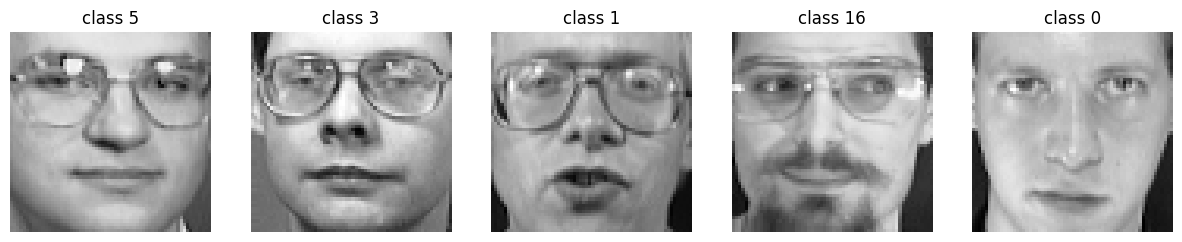

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 5, figsize=(15, 8))

for i in range(0, 5):
    ax[i].imshow(X.iloc[i].values.reshape((64, 64)), cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'class {y[i]}')

plt.show()

In [ ]:
y

array([ 5,  3,  1, 16,  0,  1, 12,  9, 26, 37, 20,  5, 10, 27, 10, 34, 13,
       26, 17, 31,  9,  7, 31, 37, 31, 35, 18, 29, 29,  4, 21, 20, 23,  7,
        9, 18, 22,  2,  1, 39, 36,  8, 34, 32,  3, 20,  3,  9, 37, 32, 34,
       15,  9, 16, 36, 16, 13,  7, 29,  6, 13,  4, 16,  0,  8,  1, 25,  3,
       18, 29,  8, 35,  2, 25, 21, 31, 35, 23, 30, 28,  4, 10, 11, 27, 29,
       39,  5, 12, 29, 26, 15,  2, 39,  6, 30, 37, 25, 32, 35, 24, 15, 24,
        2, 19, 22,  0, 38,  5, 22, 28,  6, 38,  6,  3, 33, 12, 36,  8, 27,
       19, 25, 36, 10, 37,  9, 33, 10, 28, 32, 34, 17, 23, 19, 24, 27,  3,
       39, 30,  3,  7,  3, 30, 12, 21, 17, 14, 35, 21, 19,  5, 32, 16, 19,
        8, 33, 14, 17, 15, 22, 38, 15, 18,  7, 14, 28, 39, 23, 36, 28, 10,
       39, 36, 37, 10, 34, 25, 18, 13, 19, 33, 33, 13, 26,  9, 13, 34, 24,
        0, 30, 23,  2, 22,  9, 11,  7, 35, 19, 26, 32, 11,  7,  7,  0,  4,
        0,  2,  0, 26, 21, 14,  4, 32,  1, 23, 16,  0,  7, 14, 16, 15, 39,
       17, 33, 30, 37, 17

### 3.1. KNN из sklearn

#### 3.1.1. Разбейте данные на обучение и тест

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=6, test_size=70)
X_train.shape, X_test.shape

((330, 4096), (70, 4096))

#### 3.1.2. Обучите модель KNN на 50 соседях

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 50
model = KNeighborsClassifier(n_neighbors=n_neighbors)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50)

#### 3.1.3. Проверьте качество работы модели


In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
bal_acc1 = accuracy_score(y_test, y_pred)
print(bal_acc1)

0.21428571428571427


### 3.2. Weighted KNN

#### 3.2.1. Обучите модель взвешенный KNN по дистанции

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 50
model = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance')
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 3.2.2. Проверьте качество работы модели


In [ ]:
from sklearn.metrics import balanced_accuracy_score
y_pred = model.predict(X_test)
bal_acc1 = balanced_accuracy_score(y_test, y_pred)
print(bal_acc1)

0.5416666666666667


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


### 3.3. Custom Weighted KNN

#### 3.3.1. Напишите свою функцию подсчета весов по дистанции

(Можете выбрать любой подход)

In [ ]:
def distance_cost(dists):
    return 1 / dists

#### 3.3.2. Обучите модель взвешенный KNN по написанной функции выше

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 50
model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=distance_cost)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50,
                     weights=<function distance_cost at 0x7f917812eca0>)

#### 3.3.3. Проверьте качество работы модели


In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
bal_acc1 = accuracy_score(y_test, y_pred)
print(bal_acc1)

0.4857142857142857


## KNN для регрессии

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [2]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

### Возьмите только признак MedInc и 1000 первых строк

In [3]:
mel = pd.DataFrame(X['MedInc'].head(1000))
mel

,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462
...,...
995,4.8624
996,9.1531
997,4.7361
998,5.4324


### Отрисуйте данные на графике

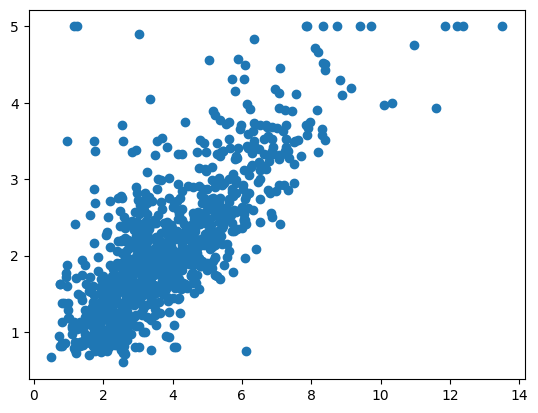

In [4]:
import matplotlib.pyplot as plt
y_plot = y[:1000]
plt.scatter(mel, y_plot)
plt.show()

### 4. KNN из sklearn

#### 4.1. Разбейте данные на обучение и тест

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    mel,              # Матрица признаков
    y_plot,              # Вектор целевых значений
    random_state=10,# Фиксируем генератор случайных чисел для воспроизводимости
    test_size=100    # Размер тестовой выборки (100 образцов)
)

X_train.shape, X_test.shape

((900, 1), (100, 1))

#### 4.2. Обучите модель KNN на 100 соседях


In [7]:
from sklearn.neighbors import KNeighborsRegressor
n_neighbors = 100

model = KNeighborsRegressor(n_neighbors=n_neighbors)

model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100)

#### 4.3. Проверьте качество работы модели


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred_test = model.predict(X_test)
r2_score(y_test, pred_test)

0.7373856697004726

#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [9]:
test1 = X_test.iloc[4]
dist = pd.DataFrame()
dist['trained'] = y_train
samp = test1.values
distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
dist['distance to 0 obj'] = distto
print(dist)

     trained  distance to 0 obj
0      3.235             4.2226
1      1.981             3.0172
2      1.703             0.6171
3      2.359             0.0573
4      1.964             1.8175
..       ...                ...
895    0.818             1.7613
896    2.102             0.6146
897    4.188             6.5906
898    3.373             2.8945
899    1.600             0.3125

[900 rows x 2 columns]


#### 4.5. Выберите топ  k  соседей


In [10]:
k = 10
d0 = dist.sort_values('distance to 0 obj').head(k)
print(d0)

     trained  distance to 0 obj
443    0.600             0.0000
708    0.893             0.0000
394    1.750             0.0000
237    1.577             0.0027
724    1.111             0.0057
489    1.200             0.0057
374    3.714             0.0063
558    0.720             0.0075
229    1.734             0.0137
391    1.702             0.0147


#### 4.6. Выведите финальное предсказание для этого объекта

In [11]:
print('pred1: ', d0['trained'].value_counts().index[0])

pred1:  0.6


#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [12]:
print(y_test[4])

1.543


#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

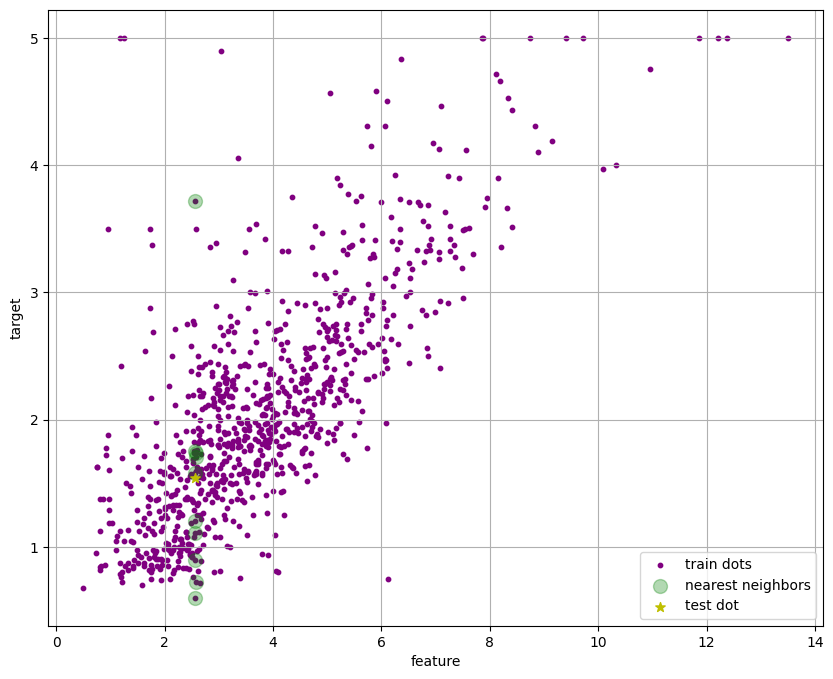

In [18]:
import matplotlib.pyplot as plt

nearest_neigbors_idxs = d0.sort_values('distance to 0 obj').head(k).index
plt.figure(figsize=(10, 8))

plt.scatter(X_train, y_train, c='purple', marker='o', s=10, label='train dots')
plt.scatter(X_train.iloc[nearest_neigbors_idxs], y_train[nearest_neigbors_idxs],
            c='g', alpha=0.3, marker='o', s=100, label='nearest neighbors')
plt.scatter(X_test.iloc[4], y_test[4], c='y', marker='*', s=50, label='test dot')
plt.grid()
plt.ylabel('target')
plt.xlabel('feature')
plt.legend()

### 5. Weighted KNN

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    mel,              # Матрица признаков
    y_plot,              # Вектор целевых значений
    random_state=10,# Фиксируем генератор случайных чисел для воспроизводимости
    test_size=100    # Размер тестовой выборки (100 образцов)
)

X_train.shape, X_test.shape

((900, 1), (100, 1))

#### 5.2. Проверьте качество работы модели


In [20]:
from sklearn.neighbors import KNeighborsRegressor
n_neighbors = 100

model = KNeighborsRegressor(n_neighbors=n_neighbors)

model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100)

#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [21]:
test1 = X_test.iloc[4]
dist = pd.DataFrame()
dist['trained'] = y_train
samp = test1.values
distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
dist['distance to 0 obj'] = distto
print(dist)

     trained  distance to 0 obj
0      3.235             4.2226
1      1.981             3.0172
2      1.703             0.6171
3      2.359             0.0573
4      1.964             1.8175
..       ...                ...
895    0.818             1.7613
896    2.102             0.6146
897    4.188             6.5906
898    3.373             2.8945
899    1.600             0.3125

[900 rows x 2 columns]


#### 5.4. Выберите топ  k  соседей


In [22]:
k = 50
d0 = dist.sort_values('distance to 0 obj').head(k)
print(d0)

     trained  distance to 0 obj
443    0.600             0.0000
708    0.893             0.0000
394    1.750             0.0000
237    1.577             0.0027
724    1.111             0.0057
489    1.200             0.0057
374    3.714             0.0063
558    0.720             0.0075
229    1.734             0.0137
391    1.702             0.0147
687    3.500             0.0170
154    2.750             0.0181
548    1.827             0.0208
222    1.599             0.0208
249    1.291             0.0224
820    1.750             0.0255
377    1.079             0.0255
120    2.038             0.0263
122    1.760             0.0273
149    0.964             0.0275
497    1.740             0.0275
462    1.659             0.0375
280    1.326             0.0375
680    1.693             0.0387
586    1.629             0.0408
696    1.247             0.0417
75     2.778             0.0425
704    0.764             0.0433
505    2.500             0.0446
190    1.349             0.0467
735    0

#### 5.5. Рассчитайте вес для каждого соседа

In [23]:
dist['weight'] = 1 / dist['distance to 0 obj']
dist['weight'].replace(np.inf, 0, inplace=True) # на случай деления на 0
dist

/tmp/ipykernel_607/979074447.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dist['weight'].replace(np.inf, 0, inplace=True) # на случай деления на 0


,trained,distance to 0 obj,weight
0,3.235,4.2226,0.236821
1,1.981,3.0172,0.331433
2,1.703,0.6171,1.620483
3,2.359,0.0573,17.452007
4,1.964,1.8175,0.550206
...,...,...,...
895,0.818,1.7613,0.567762
896,2.102,0.6146,1.627075
897,4.188,6.5906,0.151731
898,3.373,2.8945,0.345483


#### 5.6. Выведите финальное предсказание для этого объекта

In [24]:
print('pred1: ', (dist['trained'] * dist['weight']).sum() / dist['weight'].sum())

pred1:  1.7095700047174194


#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [25]:
print(y_test[4])

1.543


#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

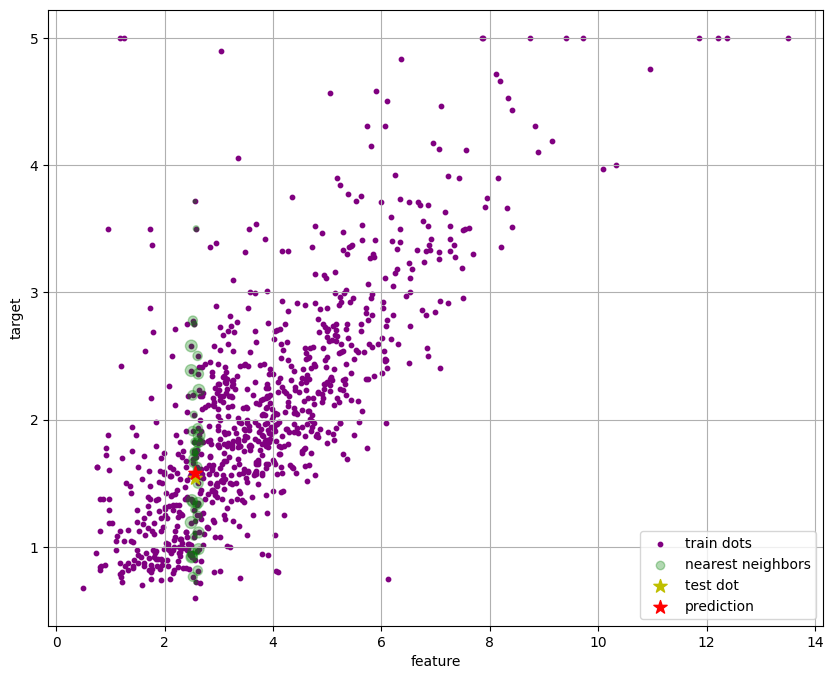

In [35]:
plt.figure(figsize=(10, 8))
nearest_neigbors_idxs = d0.sort_values('distance to 0 obj').head(k).index

print()
plt.scatter(X_train, y_train, c='purple', marker='o', s=10, label='train dots')
plt.grid()

plt.scatter(X_train.iloc[nearest_neigbors_idxs], y_train[nearest_neigbors_idxs],
            c='g', alpha=0.3, marker='o', s=dist['distance to 0 obj'].iloc[nearest_neigbors_idxs]*1000, label='nearest neighbors')

plt.scatter(X_test['MedInc'].iloc[4], y_test[4], c='y', marker='*', s=100, label='test dot')
plt.scatter(X_test['MedInc'].iloc[4], pred_test[4], c='r', marker='*', s=100, label='prediction')

plt.xlabel('feature')
plt.ylabel('target')

plt.legend()

## 6. Еще одна задача регрессии

### Получение данных

Будем работать с тем же самым набором данным `fetch_olivetti_faces` из `sklearn`, но уже для задачи регрессии - будем восстанавливать изображение.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [38]:
n_pixels = data.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2]
# Lower half of the faces
y_train = train[:, n_pixels // 2:]


X_test = test[:, :(n_pixels + 1) // 2]
y_test = test[:, n_pixels // 2:]

Вот один пример обучающей пары.

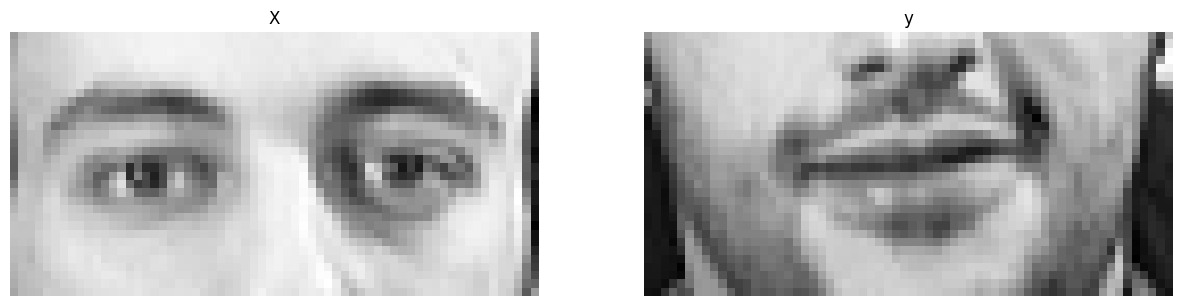

In [39]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx].reshape((32, 64)), cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx].reshape((32, 64)), cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

#### 6.1. Обучите модель KNN и назовите переменную с моделью knn на 100 соседях

In [43]:
from sklearn.neighbors import KNeighborsRegressor
n_neighbors = 100

knn = KNeighborsRegressor(n_neighbors=n_neighbors)

knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100)

#### 6.2. Проверьте качество работы модели

При этом предсказания модели запишите в словарь pred_test с ключом knn.


In [47]:
from sklearn.metrics import r2_score

pred_test = {'knn': knn.predict(X_test),
             'weighted_knn': None,
             'weighted_knn_custom': None}
print(r2_score(y_test, pred_test['knn']))

0.21050623059272766


#### 6.3. Обучите модель KNN с весами по дистанции и назовите переменную с моделью weighted_knn на 100 соседях

In [48]:
weighted_knn = KNeighborsRegressor(n_neighbors=100, weights='distance')
weighted_knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100, weights='distance')

#### 6.4. Проверьте качество работы модели

При этом предсказания модели запишите в словарь pred_test с ключом weighted_knn.


In [49]:
pred_test['weighted_knn'] = weighted_knn.predict(X_test)
print(r2_score(y_test, pred_test['weighted_knn']))

0.24241627640538166


#### 6.5. Напишите свою функцию подсчета весов по дистанции

(Можете выбрать любой подход)


In [52]:
def distance_cost(dists):
  return 1/dists

#### 6.6. Обучите модель KNN с кастомными весами по дистанции и назовите переменную с моделью weighted_knn_custom на 100 соседях

In [53]:
weighted_knn_custom = KNeighborsRegressor(n_neighbors=100, weights=distance_cost)
weighted_knn_custom.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100,
                    weights=<function distance_cost at 0x79abe4cc7ba0>)

#### 6.7. Проверьте качество работы модели

При этом предсказания модели запишите в словарь pred_test с ключом weighted_knn_custom.


In [54]:
pred_test['weighted_knn_custom'] = weighted_knn_custom.predict(X_test)
display(r2_score(y_test, pred_test['weighted_knn_custom']))

0.24241627640538166

А сейчас отрисуем все предсказания.

In [55]:
ESTIMATORS = {'knn': knn,
              'weighted_knn': weighted_knn,
              'weighted_knn_custom': weighted_knn_custom}

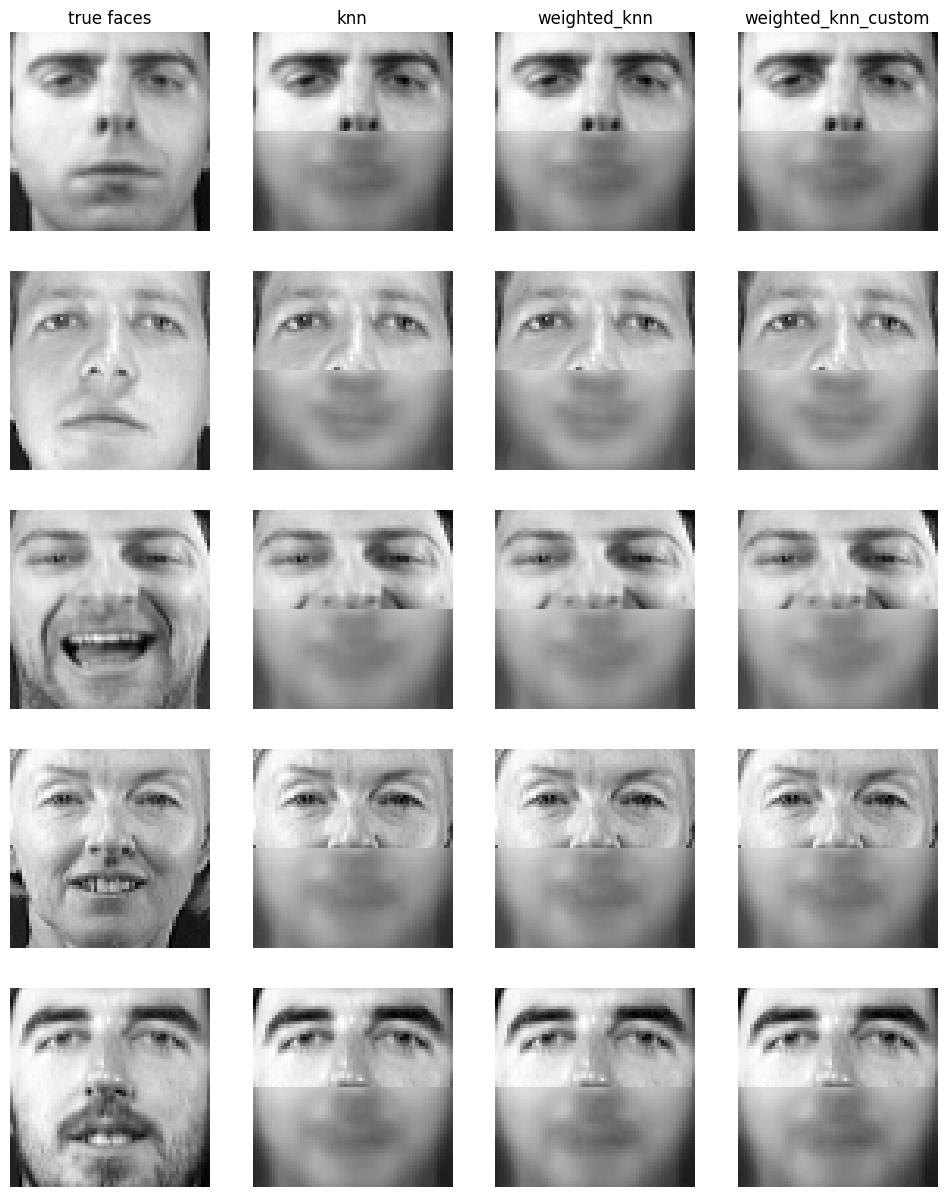

In [56]:
n_faces = 5
n_cols = 1 + len(ESTIMATORS)
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.hstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    for j, est in enumerate(sorted(ESTIMATORS)):
        completed_face = np.hstack((X_test[i], pred_test[est][i]))

        if i:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j)

        else:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j, title=est)

        sub.axis("off")
        sub.imshow(
            completed_face.reshape(image_shape),
            cmap=plt.cm.gray,
            interpolation="nearest",
        )

#### 7*. Подберите лучшие гиперпараметры для модели, используя метод [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

In [57]:
from sklearn.model_selection import GridSearchCV

param_grid = dict(n_neighbors=[i for i in range(1, 101)])
grid = GridSearchCV(knn, param_grid, cv=5)
grid.fit(X_train, y_train)

grid.best_params_

{'n_neighbors': 3}